In [3]:
import pandas as pd
import numpy as np 

In [3]:
df = pd.read_csv(r"C:\ShieldNet-AI\data/cic_aligned_training.csv")

In [10]:
df.head()
df.shape
df.columns
df.info()
df.isnull().sum()
df['Label'].value_counts()
df.replace([np.inf, -np.inf], np.nan, inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 308747 entries, 645659 to 2151551
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow Duration      308747 non-null  int64  
 1   Total Fwd Packets  308747 non-null  int64  
 2   Total Bwd Packets  308747 non-null  int64  
 3   Total Length Fwd   308747 non-null  int64  
 4   Fwd Packet Max     308747 non-null  int64  
 5   Idle Mean          308747 non-null  float64
 6   Label              308747 non-null  object 
dtypes: float64(1), int64(5), object(1)
memory usage: 18.8+ MB


In [4]:
df = pd.read_csv(r"C:\ShieldNet-AI\data/cic_aligned_training.csv")

In [5]:
print(df.shape)
print(df['Label'].unique())

(2313810, 7)
['Benign' 'Bot' 'FTP-Patator' 'SSH-Patator' 'DDoS' 'DoS slowloris'
 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye' 'Heartbleed' 'Infiltration'
 'PortScan' 'Web Attack � Brute Force' 'Web Attack � XSS'
 'Web Attack � Sql Injection']


In [6]:
df['Label'] = df['Label'].str.strip()

In [7]:
selected_labels = [
    'Benign',
    'DoS Hulk',
    'DDoS',
    'PortScan',
    'FTP-Patator'
]

df = df[df['Label'].isin(selected_labels)]

In [8]:
def map_labels(label):
    if label == 'Benign':
        return 'Benign'
    elif label == 'DoS Hulk':
        return 'DoS'
    elif label == 'DDoS':
        return 'DDoS'
    elif label == 'PortScan':
        return 'PortScan'
    elif label == 'FTP-Patator':
        return 'BruteForce'

df['Label'] = df['Label'].apply(map_labels)

In [9]:
print(df.shape)
print(df['Label'].value_counts())

(2286065, 7)
Label
Benign        1977318
DoS            172846
DDoS           128014
BruteForce       5931
PortScan         1956
Name: count, dtype: int64


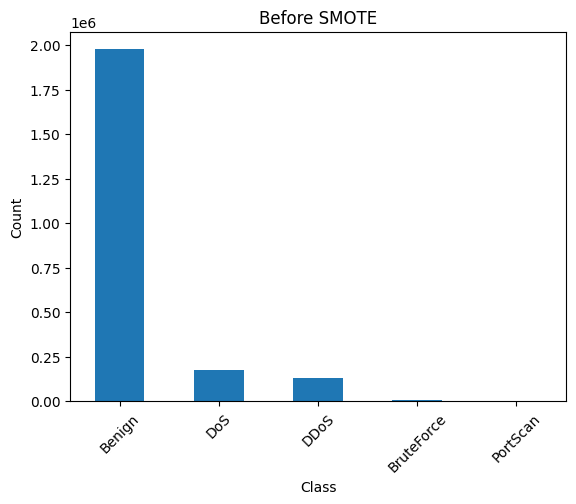

In [9]:
import matplotlib.pyplot as plt

plt.figure()
df['Label'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.title("Before SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [10]:
X = df.drop("Label", axis=1)
y = df["Label"]

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

In [12]:
X_test, X_final, y_test, y_final = train_test_split(
    X_temp, y_temp,
    test_size=0.25,   # 10% final
    stratify=y_temp,
    random_state=42
)

In [13]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Final:", X_final.shape)

Train: (1371639, 6)
Test: (685819, 6)
Final: (228607, 6)


In [14]:
print(y_train.value_counts())
print(y_test.value_counts())
print(y_final.value_counts())

Label
Benign        1186391
DoS            103707
DDoS            76808
BruteForce       3559
PortScan         1174
Name: count, dtype: int64
Label
Benign        593195
DoS            51854
DDoS           38404
BruteForce      1779
PortScan         587
Name: count, dtype: int64
Label
Benign        197732
DoS            17285
DDoS           12802
BruteForce       593
PortScan         195
Name: count, dtype: int64


In [15]:
import pandas as pd

final_df = pd.concat([X_final, y_final], axis=1)
final_df.to_csv("final_unseen_data.csv", index=False)

In [16]:
train_df = pd.concat([X_train, y_train], axis=1)

In [17]:
benign_df = train_df[train_df['Label'] == 'Benign']
attack_df = train_df[train_df['Label'] != 'Benign']

# reduce benign size (adjust if needed)
benign_sample = benign_df.sample(n=300000, random_state=42)

train_df_balanced = pd.concat([benign_sample, attack_df])

In [18]:
X_train = train_df_balanced.drop("Label", axis=1)
y_train = train_df_balanced["Label"]

In [19]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [20]:
 print(y_train.value_counts())

Label
Benign        300000
DDoS          300000
DoS           300000
BruteForce    300000
PortScan      300000
Name: count, dtype: int64


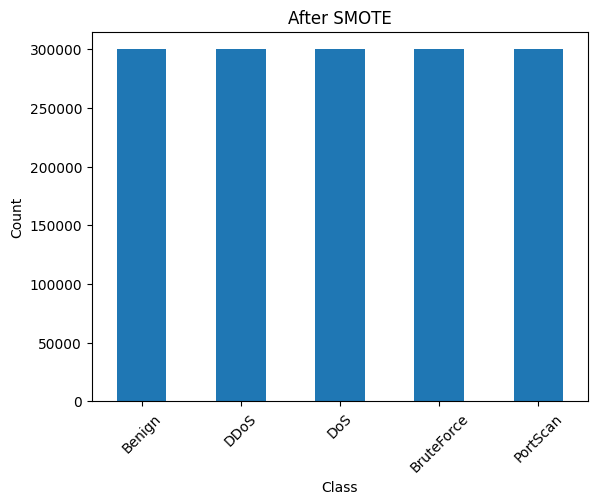

In [22]:
import matplotlib.pyplot as plt


plt.figure()
y_train.value_counts().plot(kind='bar')
plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [21]:
#Scaling 

from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_final = scaler.transform(X_final)

In [22]:
#LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)
y_final = le.transform(y_final)

In [ ]:
# Deep Neural Network (DNN) + Attention (Transformer-inspired)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Reshape, Attention, Flatten
from tensorflow.keras.optimizers import Adam

# Input
inputs = Input(shape=(X_train.shape[1],))

# Deep layers (DNN)
x = Dense(256, activation='relu')(inputs)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Dense(64, activation='relu')(x)

# FIX: reshape to 3D for attention
x = Reshape((1, 64))(x)

# Attention layer
attention = Attention()([x, x])

# Flatten back to 2D
x = Flatten()(attention)

# Output
outputs = Dense(len(set(y_train)), activation='softmax')(x)

# Model

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
# Train

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=512
)

Epoch 1/15


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


2930/2930 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9272 - loss: 0.2113 - val_accuracy: 0.8892 - val_loss: 0.2548
Epoch 2/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9617 - loss: 0.1086 - val_accuracy: 0.8278 - val_loss: 0.3895
Epoch 3/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9659 - loss: 0.0951 - val_accuracy: 0.9454 - val_loss: 0.1756
Epoch 4/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9681 - loss: 0.0881 - val_accuracy: 0.9281 - val_loss: 0.1676
Epoch 5/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9692 - loss: 0.0842 - val_accuracy: 0.9219 - val_loss: 0.1765
Epoch 6/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9701 - loss: 0.0819 - val_accuracy: 0.9114 - val_loss: 0.2245
Epoch 7/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.9707 - loss: 0.0794 - val_accuracy: 0.9005 - val_loss: 0.2611
Epoch 8/15
2930/2930 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - accuracy: 0.9713 - loss: 0.0782 - val

In [ ]:
# PREDICT ON TEST DATA

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

   99/21432 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step  

C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


21432/21432 ━━━━━━━━━━━━━━━━━━━━ 20s 944us/step


TEST DATA RESULTS:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    593195
           1       0.94      1.00      0.97      1779
           2       0.99      0.56      0.72     38404
           3       0.95      0.92      0.93     51854
           4       0.01      0.99      0.02       587

    accuracy                           0.90    685819
   macro avg       0.78      0.88      0.72    685819
weighted avg       0.99      0.90      0.94    685819



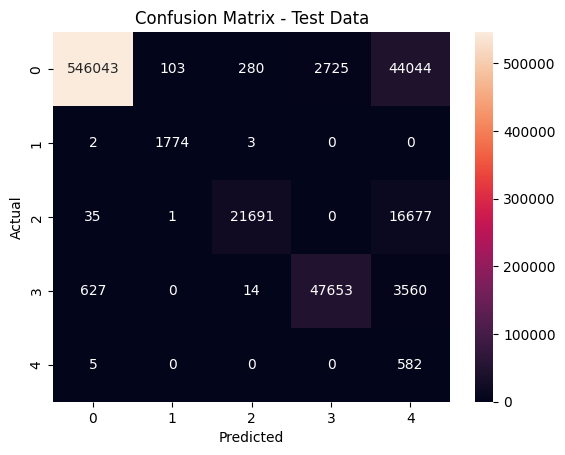

In [30]:
# EVALUATE (TEST DATA)

from sklearn.metrics import classification_report, confusion_matrix

print("TEST DATA RESULTS:")
print(classification_report(y_test, y_pred))

# CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Test Data")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [33]:
y_final_pred = model.predict(X_final)
y_final_pred = y_final_pred.argmax(axis=1)

print("FINAL DATA RESULTS:")
print(classification_report(y_final, y_final_pred))

7144/7144 ━━━━━━━━━━━━━━━━━━━━ 6s 895us/step
FINAL DATA RESULTS:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96    197732
           1       0.95      0.99      0.97       593
           2       0.98      0.57      0.72     12802
           3       0.95      0.92      0.93     17285
           4       0.01      0.98      0.02       195

    accuracy                           0.90    228607
   macro avg       0.78      0.88      0.72    228607
weighted avg       0.99      0.90      0.94    228607



In [34]:
model.save("dnn_attention_model.h5")

In [35]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']